<a href="https://colab.research.google.com/github/abigiyaDa/AfriSMAT---CM4A-2026---WORKSHOP-PROGRAM/blob/main/BC_workshop_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
---

<table style="border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:middle; width:500px;">
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/afrismat_logo.png" width="460">
</td>
<td style="border:none; vertical-align:middle;">

# **AfriSMAT  |  Circular Mechatronics for Africa (CM4A) Workshop 2026**

</td>
</tr></table>

---
---

# **Behavioural Cloning of a Safety Controller**

**135 minutes · five cells to fill.**

Train a network to copy a controller that never hurts anybody, deploy it, and
find out what it did not learn.

Blanks are marked `...`, each with a **hint above** and an **answer below the
check**. That order is deliberate.

**Six sections are marked [SELF-STUDY].** They are not covered in the sessions
and nothing later depends on them. Each says what it shows, so you can choose.

### **Notation**

| | |
|---|---|
| `s`, `û`, `u` | the state the network sees; what it proposes; what is commanded |
| `θ`, `f_θ` | the weights; the network |
| `v_h`, `v_prev` | the person's approach speed; the previous command |
| `d`, `S_p` | separation available; separation required |
| **margin** | `d − S_p`. **Negative means too close.** |
| `J`, `q̇_max` | Jacobian; the joint speed limit, 1.5 rad/s |

### **Syntax**
| construct | meaning |
|---|---|
| `X[:, i]` | every row, column `i` — the colon is "all of them" |
| `corr[name] = ...` | a dictionary: a lookup table indexed by name, not position |
| `[f(j) for j in range(2)]` | a loop written on one line, producing a list |
| `&` | "and" for arrays; **each side needs brackets** |
| `.mean()` on `True`/`False` | `True` is 1, so the mean is a fraction |
| `@` | matrix multiply — **not** `*` |
| `zip(a, b)` | walk two lists together |
| `np.concatenate([...])` | join arrays end to end — takes a **list** |
| `np.vstack([...])` | stack blocks of rows into one tall array |
| `np.c_[a, b]` | glue columns side by side |
| `A[2*m : 2*m+2, :]` | rows `2m` and `2m+1`, all columns |
| `ca.sumsqr(v)` | squared length — `v[0]**2 + v[1]**2` |
| `opti.subject_to(...)` | hands the constraint over; **without it, nothing happens** |
| `f"{x:.3f}"` | f-string; `.3f` is three decimal places |


---
## **Setup**

Run this first. The figures below will not appear until it finishes — they load
from the repository, and `pip install` takes 30–60 s on a fresh runtime.

In [28]:
import os
if not os.path.isdir('/content/ssm'):
    !git clone -q https://github.com/JohnEkD/ssm-workshop.git /content/ssm
%cd /content/ssm
import sys; sys.path.insert(0, '/content/ssm/shared/lib')
!pip -q install casadi==3.7.2 2>/dev/null

import numpy as np, matplotlib.pyplot as plt, casadi as ca
import ssm_cell as sc, ssm_viz as viz, ssm_grader as grader
import p2p_expert as pe, bc, data_loader as dl
from IPython.display import Image, HTML

D    = dl.load()
X, U = D['X'], D['U']
ep   = D['ep']
tr   = ep <  D['n_train']          # training episodes
te   = ep >= D['n_train']          # held-out episodes
X_tr, U_tr = X[tr], U[tr]
X_te, U_te = X[te], U[te]
feature_names = [str(n) for n in D['feature_names']]
action_names  = [str(n) for n in D['action_names']]

rng  = np.random.default_rng(0)
scns = [sc.sample_scenario(rng) for _ in range(62)]
print(f"  {X.shape[0]} rows over {len(np.unique(ep))} episodes"
      f"   ->  {tr.sum()} train / {te.sum()} held out")
print(f"  features {feature_names}")
print(f"  actions  {action_names}     joint limit {sc.DQ_MAX} rad/s")

/content/ssm
  PASS  found shared/data/p2p_expert_rich.npz (589 kB)
  PASS  loaded 4111 steps over 62 episodes, 26 arrays
        arrays: U, X, action_names, bin_order, bins_xy, constant_names, constants, d_pts, ep, feature_names, fixture_xy, latched, margin, n_test, n_train, op_params, op_pos, op_vel, point_names, q0, seed, seg, t, v_cap, v_tool, vh_pts
  4111 rows over 62 episodes   ->  3314 train / 797 held out
  features ['q1', 'q2', 'g1', 'g2', 'p_op_x', 'p_op_y']
  actions  ['dq1', 'dq2']     joint limit 1.5 rad/s


---
---
# **SESSION 1 — What is in the data**
### questions 1–2

---
## **1.1 The problem** — 6 min

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/d3_imitation_pipeline.png" width="760">
</center>

A controller that keeps people safe solves a nonlinear program every 100
milliseconds. That is a real cost, though not the obvious one — it is fast
enough here, at **4.27 ms** against a 100 ms budget.

The cost is that an iterative solver has **no worst case you can state**. It
usually finishes quickly; it cannot promise to. A network's forward pass takes
the same time every call. And on a bigger arm, at a higher rate, "usually
quickly" stops being good enough.

**So: can a neural network learn to do the same job?**

You have **4111 steps** of that controller running — 62 episodes of an arm
sorting parts on a bench a person keeps reaching into.

### **The rule, and it stays up all day**

> **A guess may make the robot faster. A guess may never be the reason the robot
> is allowed closer.**

The network is sometimes inaccurate — that is expected, and not the problem.
The problem is that it gives you **one number and no idea how wrong that number
is today**. You may let it speed the robot up, provided you know the largest
error it can make. You may never let it decide a safety distance can be smaller,
because a safety limit has to hold in the worst case, and the network cannot
tell you what its worst case is.

### **What the requirement actually is**

**$S_p$** is the separation the standard requires, and it depends on the
robot's own speed. When the person comes closer the robot does not retreat —
**it slows down, which shrinks $S_p$**, and the requirement is met again.

**$S_{p,\min}$** is $S_p$ with the robot stopped. Below it nothing is
compliant, including zero. Reaching it is a *layout* failure, not a control
failure.

> **The robot must never violate $S_p$.** The expert achieves 0.00 %.

---
## **1.2 What behavioural cloning is** — 8 min

Three things, and only the first is new:

$$\theta^\star = \arg\min_\theta \; \frac{1}{N}\sum_{i=1}^{N}
\left\lVert f_\theta(s_i) - u_i \right\rVert^2$$

with $N = 4111$. A dataset of (state, action) pairs from a controller that
works, a network $f_\theta$, and a loss.

No reward, no exploration, no environment during training. **It is a regression
problem** — fitting a curve to data.

> **The $\frac{1}{N}$ is the whole of §1.5.** It is an average, so a row that
> occurs 4.8 % of the time carries 4.8 % of the weight.

**A neural network, for now.** More precisely a **multilayer perceptron** — a
*feedforward* network, meaning the numbers flow one way, input to output, with
**no memory** of what came before.

It is a formula with adjustable numbers in it, called **weights**. Six numbers
in, two out, and **training** means choosing the weights so the two outputs
match what the expert did. §2.1 opens it up properly.

Not the *trajectory* — the **policy**. A trajectory can be replayed; a policy
has to work on cases it has not seen.

### **⏸ Think first**

**The expert searches.** It sets up a constrained optimisation and iterates
until it finds an action satisfying every constraint — and if none exists, it
says so.

**The network does not search.** It evaluates a fixed formula once. Same input,
same output, always. No notion of a constraint, and no way to report that there
is no safe answer.

**What could be lost?** Write down two guesses.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/bc_network.png" width="620"><br>
<em>Six numbers in, two out. §2.1 opens it up.</em>
</center>

---
> ### **[SELF-STUDY] 1.2b — where this came from**
>
> **~5 min. What it shows:** Pomerleau's ALVINN drove a van at half a metre per
> second in 1989 using exactly this method — one hidden layer, 29 units, a 30×32
> camera retina, 1200 simulated road images. The paper already names the failure
> this workshop is about: the network *"must not solely be shown examples of
> accurate driving, but also how to recover once a mistake has been made."*
>
> Reference at the end of the notebook.

---
## **1.3 One episode, twice** — 10 min

**As a robot.** The arm sorts, the person reaches in, the arm slows, the person
withdraws, the arm speeds up.

In [29]:
EP = 3
log_expert = sc.simulate(pe.build()[0], scns[EP], label=f'expert, episode {EP}')
z_expert   = sc.audit(log_expert)

> `audit` must run before any plot or animation — it adds `margin`, `d_worst`
> and `Sp_worst` to the log, which `simulate` does not produce.

**Rendering the animation takes 10–20 seconds.** That is not a hang.

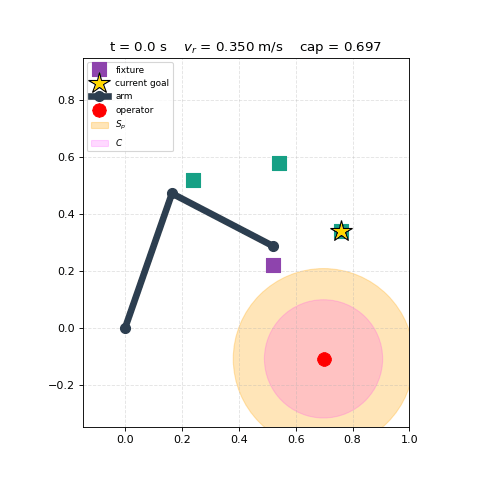

In [30]:
anim = viz.animate_run(log_expert)
anim.save('expert.gif', writer='pillow', fps=10, dpi=80)
plt.close('all')
Image(filename='expert.gif')

**Now as data.** One frame of that animation is one row of numbers.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/frame_to_row.png" width="700">
</center>

In [31]:
print('  one row, and there are', len(X), 'of them\n')
print('   ', '  '.join(f'{n:>8s}' for n in feature_names + action_names))
print('   ', '  '.join(f'{v:8.3f}' for v in np.r_[X[500], U[500]]))

  one row, and there are 4111 of them

          q1        q2        g1        g2    p_op_x    p_op_y       dq1       dq2
       1.438    -1.735     1.161    -1.801     0.539    -0.101    -0.581    -0.041


---
> ### **[SELF-STUDY] 1.3b — the data itself**
>
> **~5 min. What it shows:** no missing values, no duplicates, 62 episodes of
> 57–77 rows. The six columns are on scales that differ by **13×** —
> `p_op_y` varies by 0.032, `g2` by 0.423 — which is why the model standardises
> its inputs. And `dq2` is at the joint limit on **6.8 %** of rows: the elbow is
> regularly driven flat out. Remember that when you meet the output `tanh` in
> §2.1.

In [32]:
# [SELF-STUDY] the standard checks, in the order you would always do them
print(f"  {X.shape[0]} rows, {X.shape[1]} features, {U.shape[1]} actions")
print(f"  missing values : {np.isnan(X).sum() + np.isnan(U).sum()}")
print(f"  duplicate rows : {len(X) - len(np.unique(X, axis=0))}\n")
for i, n in enumerate(feature_names):
    print(f"  {n:8s} mean {X[:, i].mean():+7.3f}   sd {X[:, i].std():6.3f}")
print()
for i, n in enumerate(action_names):
    at = 100 * (np.abs(U[:, i]) > 0.9999 * sc.DQ_MAX).mean()
    print(f"  {n:5s} sd {U[:, i].std():6.3f}   at the joint limit on {at:5.2f} % of rows")

  4111 rows, 6 features, 2 actions
  missing values : 0
  duplicate rows : 0

  q1       mean  +1.276   sd  0.271
  q2       mean  -1.513   sd  0.326
  g1       mean  +1.251   sd  0.336
  g2       mean  -1.506   sd  0.423
  p_op_x   mean  +0.551   sd  0.122
  p_op_y   mean  -0.074   sd  0.032

  dq1   sd  0.484   at the joint limit on  0.00 % of rows
  dq2   sd  0.763   at the joint limit on  6.81 % of rows


---
## **1.4 What the network is given** — 12 min

Six numbers in — `q1, q2, g1, g2, p_op_x, p_op_y`. Two out — `dq1, dq2`.

> **These six are a choice, and you should be suspicious of it.** They mirror
> the published work, and they mirror what a real cell can sense — **no
> safety-rated sensor reports how fast a person is approaching.** Whether the
> choice is survivable is what sessions 2 and 3 test.

### **⏸ Predict first**

The expert's behaviour depends heavily on the person. **How strongly should the
operator columns correlate with the commands?** Write a number down.

### **Question 1 — the correlation table**

> Compute the correlation between every input column and every output column,
> then read off how strongly the two operator columns relate to the commands.

<details>
<summary><b>Hint</b></summary>

`np.corrcoef(a, b)[0, 1]` gives one correlation.

`corr[name] = [...]` adds one entry to a **dictionary**. The `[... for j in range(2)]` inside is a **list comprehension** — a loop written on one line that produces a list. You want the correlation of this feature with each of the two actions.

</details>

In [35]:
corr = {}
for i, name in enumerate(feature_names):
    corr[name] = [ np.corrcoef(X[:, i], U[:, j])[0, 1] for j in range(U.shape[1]) ]   # r between this feature and each action

In [36]:
grader.q_d3_corr(corr, feature_names)

  PASS  1.1  you correlated every feature with both actions
  PASS  1.2  correlations are between -1 and 1
  PASS  1.3  the goal columns carry the signal
  PASS  1.4  the operator columns do not


True

<details>
<summary><b>Show the answer</b></summary>


```python
corr[i, j] = np.corrcoef(X[:, i], U[:, j])[0, 1]
```


</details>

In [37]:
print('               ' + '  '.join(f'{n:>7s}' for n in action_names))
for n in feature_names:
    print(f'  {n:11s} ' + '  '.join(f'{r:+7.3f}' for r in corr[n]))

                   dq1      dq2
  q1           -0.129   +0.009
  q2           +0.196   -0.126
  g1           +0.647   -0.209
  g2           -0.262   +0.743
  p_op_x       -0.008   -0.000
  p_op_y       +0.015   -0.024


**Goal columns: strong. Operator columns: $|r| < 0.02$** — essentially nothing.

That does not mean the person is irrelevant. The influence is **conditional** —
enormous in the rows where safety is the limit in force, absent elsewhere. A linear
correlation over 4111 rows cannot see a conditional effect.

---
## **1.5 How often is safety the limit?** — 9 min

The speed cap is either **the one in force** — the thing actually slowing the arm — or it is not, in
which case the arm is going as fast as the task allows and safety is not in
play.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/rare_rows.png" width="660">
</center>

### **Question 2 — when is safety the limit?**

> Build a boolean mask that is `True` on the rows where the speed cap is the
> limit that is slowing the arm, then take its mean to get the fraction.

<details>
<summary><b>Hint</b></summary>

Two conditions, combined with `&`: the cap `D['v_cap']` is below the carry limit `sc.V_CARRY`, **and** the tool is actually going about that fast — `D['v_tool']` close to the cap.

`&` combines two conditions element by element across a whole array. **Each condition needs its own brackets** — `(a < b) & (c > d)` — because `&` binds tighter than `<`. Use `&`, not `and`; `and` does not work on arrays.

</details>

In [39]:
active = (D['v_cap'] < sc.V_CARRY * 0.999) & (D['v_tool'] > 0.98 * D['v_cap'])
print(f"  safety is the limit on {100 * active.mean():.1f} % of rows"
      f"   ({active.sum()} of {len(active)})")

  safety is the limit on 4.7 % of rows   (195 of 4111)


In [40]:
grader.q_active(active, D, sc.V_CARRY)

  PASS  SSM is the active limiter on a small minority of steps
  PASS  the tool is slower where SSM binds


True

<details>
<summary><b>Show the answer</b></summary>


```python
active = (D['v_cap'] < sc.V_CARRY * 0.999) & (D['v_tool'] > 0.98 * D['v_cap'])
```

Two conditions. The cap has to be **below** the carry limit — otherwise it is
the task, not safety, doing the limiting. And the tool has to be **at** the cap
— otherwise the limit exists but nothing is pressed against it.


The variable is called `active` because in optimisation a constraint that is in force is called **active**, or **binding** — and **slack** when it is not. You will meet those words in the literature; *the limit in force* is the same idea.

</details>

**4.8 %.** 196 rows of 4111.

> **The training error is an average over all 4111 rows.** The 196 rows where
> safety matters are 4.8 % of that average — so getting all of them completely
> wrong barely changes it.
>
> That sentence is the whole of session 2.

---
---
# **SESSION 2 — Training it, and deploying it**
### question 3

---
## **2.1 What a neural network is** — 12 min

A stack of two operations, repeated.

**Multiply and add.** Take the six inputs, multiply each by a weight, add them
up, add one more number called a bias. Do that 64 times with 64 different sets
of weights, and you have 64 new numbers.

**Squash.** Push each through `tanh`, which flattens anything large towards
$+1$ or $-1$.

Repeat, and you have a **layer**. This network has three:

$$h^{(1)} = \tanh\!\left(W_1^{\top} s + b_1\right)$$
$$h^{(2)} = \tanh\!\left(W_2^{\top} h^{(1)} + b_2\right)$$
$$\hat u = \dot q_{\max}\tanh\!\left(W_3^{\top} h^{(2)} + b_3\right)$$

| | shape | |
|---|---|---|
| $s$ | 6 | the inputs |
| $W_1, b_1$ | 6×64, 64 | first layer |
| $W_2, b_2$ | 64×64, 64 | second layer |
| $W_3, b_3$ | 64×2, 2 | output layer |
| $\hat u$ | 2 | the two joint speeds |

Notation follows **Goodfellow, Bengio and Courville (2016), ch. 6**. In the code
the same thing is written `h @ W`, because NumPy keeps the data in rows —
identical arithmetic, transposed convention.

The middle layers are called **hidden** because you neither set them nor read
them.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/network_weights.png" width="700">
</center>

In [41]:
m0 = bc.MLP()
w = sum(a.size for a in m0.W); b = sum(a.size for a in m0.b)
for i, (W, B) in enumerate(zip(m0.W, m0.b)):
    print(f"  layer {i+1}:  W {str(W.shape):9s} = {W.size:5d} weights,  b({B.size})")
print(f"\n  {w} weights + {b} biases = {w + b} numbers. That is the whole model.")

  layer 1:  W (6, 64)   =   384 weights,  b(64)
  layer 2:  W (64, 64)  =  4096 weights,  b(64)
  layer 3:  W (64, 2)   =   128 weights,  b(2)

  4608 weights + 130 biases = 4738 numbers. That is the whole model.


### **Question 4 — the forward pass**

You have the weights. **This is everything a trained network does with them.**

> Write the one line inside the loop: multiply by the weights, add the bias,
> squash with `tanh`.

The standardisation and the output scaling are given — those are the two things
either side of the network proper.

<details>
<summary><b>Hint</b></summary>

`h @ W` is the matrix product — `@`, not `*`.

Then add `b`, then `np.tanh(...)` around the whole thing. One line, three operations, in that order.

</details>

In [42]:
def forward(model, s):
    """One forward pass: six numbers in, two joint speeds out."""
    h = (np.atleast_2d(s) - model.mu) / model.sd     # standardise, as fit did
    for W, b in zip(model.W, model.b):
        h = np.tanh(h @ W + b)                                      # multiply, add bias, squash
    return sc.DQ_MAX * h                             # scale to rad/s

In [43]:
# a quickly-trained network, just to have real weights to check against
m_chk = bc.MLP(); m_chk.fit(X_tr, U_tr, epochs=200, verbose=False)

mine   = forward(m_chk, X_te)
theirs = m_chk.predict(X_te)
gap    = np.abs(mine - theirs).max()
print(f"  checked on {len(mine)} held-out rows")
print(f"  largest disagreement with the library : {gap:.2e}")
print(f"  {'PASS' if gap < 1e-12 else 'FAIL'}   your forward pass IS the network")
print(f"\n  output range {mine.min():+.4f} to {mine.max():+.4f}"
      f"   -- the limit is +/- {sc.DQ_MAX}, and it cannot be crossed")

  checked on 797 held-out rows
  largest disagreement with the library : 0.00e+00
  PASS   your forward pass IS the network

  output range -1.4801 to +1.3826   -- the limit is +/- 1.5, and it cannot be crossed


<details>
<summary><b>Show the answer</b></summary>

```python
        h = np.tanh(h @ W + b)
```

**That one line, three times, is the whole network.** The loop runs once per layer; `h` starts as the six standardised inputs and ends as two numbers in (-1, +1).

Everything else in `bc.py` — 92 lines of it — exists to *choose* `W` and `b`. Once they are chosen, this is all that happens at run time.

And note the last line of the function: whatever the loop produces is bounded by `tanh`, so multiplying by `DQ_MAX` gives something that **cannot** exceed the joint limit.

</details>

### **Watch it train**

The next cell trains a network from scratch and draws what happens. Left: the
weights. Right: the error it is minimising.

> **It takes about 20 seconds** — 600 epochs and 31 frames. That is not a hang.
>
> This is a **demonstration**, on its own network. The model you will use is
> trained in §2.3, for 4000 epochs. This one stops at 600, which is enough to
> show the shape of the curve.

In [44]:
from matplotlib.animation import FuncAnimation
ARM, ACC, PERSON, MUTE, ORANGE = '#1f3a5f', '#0b6e5f', '#c0392b', '#7a8794', '#b5651d'

demo, CH, N_CH = bc.MLP(), 20, 30
snaps = [(0, [w.copy() for w in demo.W],
          float(np.mean((demo.predict(X_tr) - U_tr) ** 2)))]
for k in range(N_CH):
    demo.fit(X_tr, U_tr, epochs=CH, verbose=False)
    snaps.append(((k + 1) * CH, [w.copy() for w in demo.W],
                  float(np.mean((demo.predict(X_tr) - U_tr) ** 2))))
print(f"  MSE  {snaps[0][2]:.2e}  ->  {snaps[-1][2]:.2e}"
      f"   ({snaps[0][2] / snaps[-1][2]:.0f}x smaller)")

  MSE  1.09e+00  ->  3.85e-04   (2826x smaller)


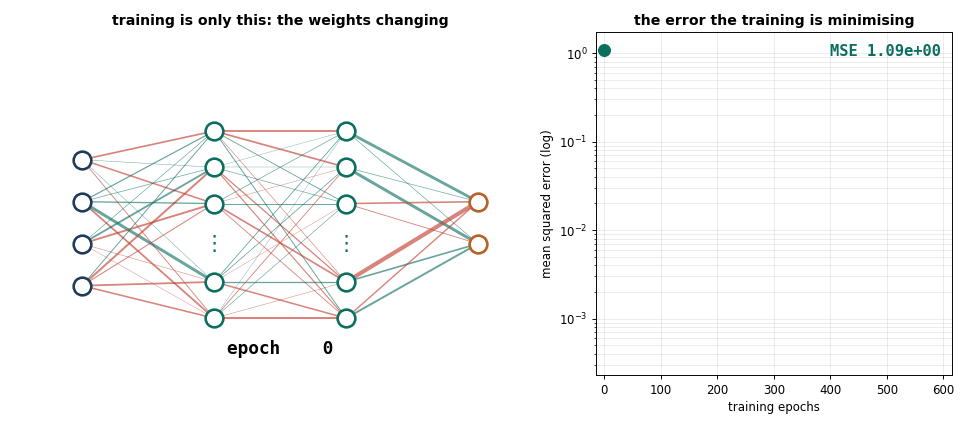

In [45]:
rv   = np.random.default_rng(1)
SHOW = [4, 5, 5, 2]
idx  = [np.array([(rv.integers(0, snaps[0][1][L].shape[0]),
                   rv.integers(0, snaps[0][1][L].shape[1]))
                  for _ in range(SHOW[L] * SHOW[L + 1])]) for L in range(3)]
xs   = [0.09, 0.37, 0.65, 0.93]
def col_ys(n, c=0.46):
    if n == 4: return [c+.165, c+.055, c-.055, c-.165]
    if n == 2: return [c+.055, c-.055]
    return [c+.24, c+.145, c+.05, c-.155, c-.25]
ys   = [col_ys(n) for n in SHOW]
# per LAYER: layer 1's weights are ~3x layers 2 and 3, so one global
# scale would render the later layers invisible
WMAX = [max(np.abs(s[1][L]).max() for s in snaps) for L in range(3)]
eps, mses = [s[0] for s in snaps], [s[2] for s in snaps]

fig_, ax_ = plt.subplots(1, 2, figsize=(11.4, 5.0),
                         gridspec_kw={'width_ratios': [1.35, 1]})
ax_[1].set_yscale('log')
ax_[1].set_xlim(-15, eps[-1] + 15); ax_[1].set_ylim(min(mses)*.6, max(mses)*1.6)
ax_[1].set_xlabel('training epochs'); ax_[1].set_ylabel('mean squared error (log)')
ax_[1].set_title('the error the training is minimising', weight='bold')
ax_[1].grid(alpha=.25, which='both')
(curve,) = ax_[1].plot([], [], color=ACC, lw=2.6)
(pt,)    = ax_[1].plot([], [], 'o', color=ACC, ms=10)
lbl = ax_[1].text(.97, .93, '', transform=ax_[1].transAxes, fontsize=13,
                  color=ACC, ha='right', weight='bold', family='monospace')

def draw(f):
    e, Ws, mse = snaps[f]
    ax_[0].clear(); ax_[0].set_xlim(0, 1.02); ax_[0].set_ylim(.06, .96)
    ax_[0].axis('off')
    for L in range(3):
        pairs = [(a, b) for a in ys[L] for b in ys[L + 1]]
        for (i, j), (ya, yb) in zip(idx[L], pairs):
            wv = Ws[L][i, j] / WMAX[L]
            ax_[0].plot([xs[L], xs[L+1]], [ya, yb],
                        color=ACC if wv > 0 else PERSON,
                        lw=0.3 + 4.0*min(abs(wv), 1), alpha=.62, zorder=1)
    for c, (x, yy) in enumerate(zip(xs, ys)):
        col = [ARM, ACC, ACC, ORANGE][c]
        for y in yy:
            ax_[0].plot(x, y, 'o', color='white', mec=col, mew=2.2, ms=15, zorder=4)
        if c in (1, 2):
            ax_[0].text(x, .405, '⋮', fontsize=18, color=col, ha='center', va='center')
    ax_[0].set_title('training is only this: the weights changing', weight='bold')
    ax_[0].text(.51, .115, f'epoch {e:>4d}', fontsize=15, ha='center',
                weight='bold', family='monospace')
    curve.set_data(eps[:f+1], mses[:f+1]); pt.set_data([e], [mse])
    lbl.set_text(f'MSE {mse:.2e}')
    return ()

fig_.tight_layout()
FuncAnimation(fig_, draw, frames=len(snaps), interval=220).save(
    'training.gif', writer='pillow', fps=5, dpi=85)
plt.close('all')
Image(filename='training.gif')

Two things to take from that.

**The weights change, and that is all that changes.** The shape of the network,
the number of layers, the `tanh` — none of it moves. Training is 4,738 numbers
being nudged.

**The error falls fast, then crawls.**

> **It never reaches zero, and it does not need to.** A small error is not the
> same as a safe error — which is what §2.4 is about.

### **Why squash at all?**

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/tanh_explained.png" width="720">
</center>

Without it, multiply-and-add stacked on multiply-and-add is still just
multiply-and-add — the whole network would collapse into one layer and could
only draw straight lines.

**And on the output layer it does a second job.** Whatever the last layer
computes — 3, or 14, or 14 000 — `tanh` returns something between $-1$ and
$+1$. Multiply by $\dot q_{\max}$ and the network **physically cannot command
a speed above the joint limit**, for any weights, on any input, however badly
the training went.

> That is the one safety property you get from the architecture rather than
> from the training. It is worth knowing exactly which one it is, because it is
> the only one.

In [47]:
for z in (-14.0, -2.0, 0.4, 3.0, 14.0):
    print(f"  z = {z:+6.1f}   ->   tanh(z) = {np.tanh(z):+.4f}"
          f"   ->   command {sc.DQ_MAX * np.tanh(z):+.4f} rad/s")
print(f"\n  the joint limit is +/- {sc.DQ_MAX} rad/s, and it cannot be exceeded")

  z =  -14.0   ->   tanh(z) = -1.0000   ->   command -1.5000 rad/s
  z =   -2.0   ->   tanh(z) = -0.9640   ->   command -1.4460 rad/s
  z =   +0.4   ->   tanh(z) = +0.3799   ->   command +0.5699 rad/s
  z =   +3.0   ->   tanh(z) = +0.9951   ->   command +1.4926 rad/s
  z =  +14.0   ->   tanh(z) = +1.0000   ->   command +1.5000 rad/s

  the joint limit is +/- 1.5 rad/s, and it cannot be exceeded


---
> ### **[SELF-STUDY] 2.1b — why tanh, and why not an LSTM**
>
> **~10 min. What it shows:** why a saturating activation rather than a ReLU
> here, and what a recurrent network would and would not fix.
>
> An LSTM would make `v_prev` representable, and could partly infer `v_h` from
> position history. But an inferred approach speed is still a **point
> estimate**, and the rule in §1.1 says a point estimate may never relax a hard
> constraint. It might reduce the error; **it would not change the
> certification argument.**

---
## **2.2 Choosing what it can see** — 10 min

### **Question 3 — the features**

> Write `features(q, q_goal, p_op)`. It returns one array of six numbers, in
> the order the network expects: the two joint angles, then the two goal
> coordinates, then the two operator coordinates.

<details>
<summary><b>Hint</b></summary>

`np.concatenate([...])` joins arrays end to end.

Three two-element arrays in, one six-element array out.

</details>

In [48]:
def features(q, q_goal, p_op):
    return np.concatenate([q, q_goal, p_op])

In [49]:
grader.q_features(features, X)

  PASS  features() returns six numbers
  PASS  features() matches the stored column order


True

<details>
<summary><b>Show the answer</b></summary>


```python
def features(q, q_goal, p_op):
    return np.concatenate([q, q_goal, p_op])
```

Order matters. The network was trained on columns in this order; hand it the
same six numbers shuffled and every weight is attached to the wrong input.


</details>

Two lines. The point is not the code — **you are choosing what the network can
see**, and anything you leave out is unavailable to it forever.

**Two quantities the expert used are not among these six.** Find them and you
have predicted session 3.

---
## **2.3 Training, and one detail that matters** — 8 min

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/train_holdout.png" width="700">
</center>

Adam, $\alpha = 10^{-3}$, $\beta_1 = 0.9$, $\beta_2 = 0.999$,
$\varepsilon = 10^{-8}$, mini-batches of 256, 4000 epochs.

**The inputs are standardised inside the model.** `fit` computes the mean and
standard deviation of each column on the training set and stores them;
`predict` reapplies them. **The same transform must be applied at inference** —
a network fed raw inputs when it was trained on standardised ones produces
confident nonsense.

**The targets are scaled into tanh space**, $u / \dot q_{\max}$, so the loss
is dimensionless.

**The split is grouped by episode, not shuffled by row.**

In [50]:
same_ep = np.diff(ep) == 0
d_consec = np.linalg.norm(np.diff(X, axis=0), axis=1)[same_ep].mean()
r = np.random.default_rng(0)
d_random = np.linalg.norm(X[r.integers(0, len(X), 4000)]
                          - X[r.integers(0, len(X), 4000)], axis=1).mean()
print(f"  consecutive rows in one episode : {d_consec:.3f} apart")
print(f"  two random rows                 : {d_random:.3f} apart"
      f"   ({d_random / d_consec:.0f}x further)")

  consecutive rows in one episode : 0.147 apart
  two random rows                 : 0.893 apart   (6x further)


Shuffle by row and the same moment lands in both halves, so the held-out error
measures memorisation. Grouped, it is about **27 times larger** and honest.

In [51]:
model = bc.MLP()
model.fit(X_tr, U_tr, epochs=4000, verbose=False)
print(f"  training MSE  {np.mean((model.predict(X_tr) - U_tr) ** 2):.3e}")
print(f"  held-out MSE  {np.mean((model.predict(X_te) - U_te) ** 2):.3e}")
grader.q_clone(model, X_te, U_te, sc.DQ_MAX)

  training MSE  1.538e-04
  held-out MSE  5.859e-04
  PASS  the output respects the joint-rate bound by construction


True

By every number available at training time, this worked.

---
> ### **[SELF-STUDY] 2.3b — defeat the standardisation**
>
> **~5 min. What it shows:** set `m.mu, m.sd = 0, 1` and retrain. Held-out
> error roughly **doubles**, 9.8e-4 → 2.0e-3. Less than the 13× scale
> difference would suggest, because **Adam adapts each parameter's step size and
> hides most of the problem.** What it does not hide is `tanh` saturation: raw
> inputs of magnitude ~1.4 push the first layer into the flat part of the curve,
> where gradients nearly vanish.
>
> **A second experiment.** The code initialises weights from
> $\mathcal{N}(0, \sqrt{2/n_{in}})$ — He initialisation, which was derived for
> **ReLU**. This network uses `tanh` throughout, for which the conventional
> choice is Glorot with variance $2/(n_{in}+n_{out})$. Swap it and see whether
> it matters.

---
## **2.4 Deploying it** — 15 min

Take the trained network, put it where the expert was, run the same scenarios.
Nothing else changes.

### **⏸ Predict first**

The published figure for this experiment is **33 %** violations. What do you
expect here?

In [52]:
policy = bc.as_policy(model)
test   = [i for i in range(62) if i >= D['n_train']]
z_unf  = sc.aggregate([sc.audit(sc.simulate(policy, scns[i], label=f'bc{i}'))
                       for i in test])
grader.q_unfiltered(z_unf)

  PASS  solver failures are zero
  PASS  the clone violates where the expert did not


True

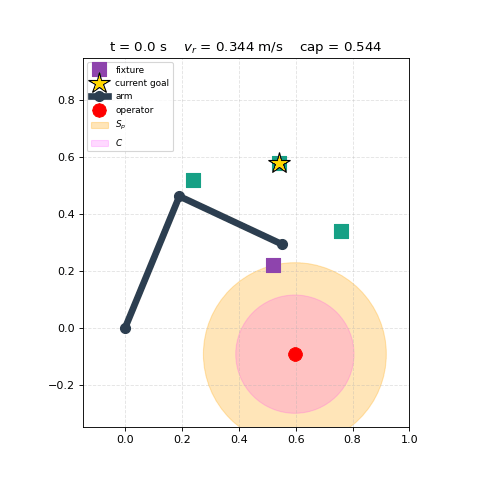

In [53]:
log_clone = sc.simulate(policy, scns[50], label='clone, episode 50')
sc.audit(log_clone)
anim = viz.animate_run(log_clone)
anim.save('clone.gif', writer='pillow', fps=10, dpi=80)
plt.close('all')
Image(filename='clone.gif')

It does the job, and it hurts somebody on a small fraction of steps.

> **The training loss did not see this coming.** It could not — the 196
> critical rows were 4.8 % of the average, and the network minimised the
> average.

**And it is not one unlucky episode.** Across 250 unseen scenarios, **163 show
at least one violation.**

### **Where session 2 ends**

Do not explain it. **Write down what you think went wrong** and bring it
tomorrow. Most people say the same thing, and most people are wrong.

---
---
# **SESSION 3 — Diagnosis, and what a filter can fix**
### questions 4–5

---
## **3.1 The obvious explanation** — 6 min

**Covariate shift** — the clone makes a small error, which puts it in a state
slightly unlike anything in its training data, where it makes a larger error,
and so on.

**This is not folklore.** Ross, Gordon and Bagnell proved that a classifier
with error $\epsilon$ under the expert's distribution can make $T^2\epsilon$
mistakes under its own, because as soon as the learner errs it may encounter
completely different observations, compounding the error. **The bound is
tight.**

The standard fix is **DAGGER (Dataset Aggregation)**: run the clone, ask the
expert what it would have done at each state the clone actually reached, add
those pairs to the training set, retrain, and repeat.

> **We will not run DAGGER (Dataset Aggregation) in the session** — §3.2 shows
> why. If you want to run it anyway and check, section 3.2b sets it out.

**Before reaching for it, measure.**

---
## **3.2 Is it drift?** — 16 min

If the clone were drifting into unfamiliar territory, its states would be
**further from the training data** than the expert's states are. That is a
measurable claim.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/nn_distance.png" width="580">
</center>

### **Question 5 — nearest-neighbour distance**

> The clone's distance is already written. Add the expert's, as a control —
> the same measurement on states the expert visited.

<details>
<summary><b>Hint</b></summary>

One word. The clone's line above simulates `policy`; yours has to simulate the expert instead.

Everything else is identical, and that is the point — same episodes, same state definition, same reference set. Change any of those and it stops being a control.

</details>

In [54]:
# the full six-feature state, from a log
def state_of(lg):
    return np.c_[lg['q1'], lg['q2'], lg['g1'], lg['g2'], lg['hx'], lg['hy']]

step_expert, _ = pe.build()

# both policies on the SAME held-out episodes -- otherwise it is not a control
S_clone  = np.vstack([state_of(sc.simulate(policy, scns[i], label='c')) for i in test])
S_expert = np.vstack([state_of(sc.simulate(step_expert, scns[i], label='e')) for i in test])

d_clone  = sc.nn_distance(S_clone,  X_tr)
d_expert = sc.nn_distance(S_expert, X_tr)
print(f"  expert {d_expert.mean():.3f}   clone {d_clone.mean():.3f}")

  expert 0.328   clone 0.332


In [55]:
grader.q_no_drift(d_clone, d_expert)

  PASS  the clone does NOT drift away from the training data


True

<details>
<summary><b>Show the answer</b></summary>

```python
S_expert = np.vstack([state_of(sc.simulate(step_expert, scns[i], label='e')) for i in test])
```

**A distance on its own means nothing.** 0.332 could be near or far. It becomes evidence only against the expert's number on the **same episodes**, with the **same six features** — run them on different scenarios and you are measuring the scenarios, not the policies.

</details>

**No drift.** The clone is standing exactly where the expert stood, and doing
something different.

> **This is not covariate shift, and DAGGER (Dataset Aggregation) would not fix
> it.** Adding more data around states the clone already knows would change
> nothing.

That is the day's turn: a correct, well-founded theory whose **precondition is
measurably absent**.

---
> ### **[SELF-STUDY] 3.2b — DAGGER (Dataset Aggregation): collect more data where the clone actually goes**
>
> **~30 min, open-ended. What it shows:** whether the prediction above holds.
>
> The loop, in about twenty lines:
>
> 1. Run the clone across the training scenarios, keeping every state it visits
> 2. For each, ask the **expert** what it would have commanded there
> 3. Add those `(state, expert action)` pairs to the dataset
> 4. Retrain on everything collected so far
> 5. Repeat for three or four iterations
>
> Everything you need exists — `pe.build()` gives the expert,
> `bc.as_policy(model)` gives the clone, and `fit` continues from the weights it
> already has.
>
> **What to measure.** Violation rate and worst breach after each iteration, and
> the nearest-neighbour distance, to confirm it stays flat.
>
> **What to expect.** The violation rate should not improve much. DAGGER will
> collect a state where the expert commanded 0.1 rad/s because the person was
> approaching quickly — and the dataset already holds near-identical states
> where the expert commanded 0.4 because they were standing still. **Adding the
> new pair moves the conditional mean; it does not resolve the conflict**,
> because the two rows are indistinguishable in the six features.
>
> **If it does improve substantially, that is more interesting than if it does
> not.** Check first whether the improvement survives on scenarios that were
> never in any iteration.
>
> Ross, Gordon and Bagnell (2011), Algorithm 3.1, has the full procedure
> including the $\beta$ schedule for mixing in the expert during early
> iterations.

---
## **3.3 So what is it?** — 6 min

Two quantities the expert used are missing, and they are missing in
**different ways**.

**`v_h`, the operator's approach speed**, sets the cap and appears three times
in its formula. It is not an input — the network gets *where* the person is,
not how fast they are moving.

**`v_prev`, the previous command**, drives the rate limit. A **feedforward**
network has no memory, so it could not use this even if it were supplied.

Two rows with identical features can therefore have different correct actions.
The best a memoryless network can do is the **conditional mean** — and
averaging "slow down hard" with "carry on" gives neither.

**The network cannot see what it would need to get this right.**
Unobservability, not drift.

Two fixes, and only one is a fix:

**Add the missing features** — correct, and requires a safety-rated velocity
sensor that does not exist.

**Put a filter outside the network** — cheaper, and honest about what the
network is.

---
## **3.4 The safety filter** — 16 min

Let the network propose. Then find the nearest allowed action.

$$\min_u \; \lVert u - \hat u \rVert^2 \quad \text{s.t.} \quad
\lVert J_i(q)\,u \rVert^2 \le v_{\max,i}^2, \quad
\lVert J_t u \rVert^2 \le v_{\text{carry}}^2, \quad
|u| \le \dot q_{\max}$$

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/filter_projection.png" width="560">
</center>

**That first constraint is Question 6 from the last workshop, unchanged.** Same
four monitored points, same squared form.

> **Note what we have done.** The reason for cloning the controller was that a
> solver has no worst case you can state — and the fix is **another solver**.
> The difference is that this one is convex, so it has a solution guaranteed in
> advance, and $u = 0$ is always in the feasible set. **It cannot fail; it can
> only slow the robot down.**

### **Question 6 — the safety filter**

> Two blanks. The first is the vector whose squared length the cap bounds — the
> Jacobian of point *m* times `u`. The second is the objective: minimise the
> squared distance between `u` and what the network proposed.

<details>
<summary><b>Hint</b></summary>

`ca.sumsqr(v)` is the squared length of `v`.

`p_J[2*m:2*m+2, :]` is the 2×2 Jacobian block for monitored point *m*, and `@` is the matrix product — **not** `*`, which multiplies element by element and gives the wrong shape with no error.

</details>

In [56]:
opti, u, p_uhat, p_cap, p_J, p_Jt = sc.filter_scaffold()
for m in range(len(sc.MONITORED)):
    opti.subject_to(ca.sumsqr(p_J[2*m:2*m+2, :] @ u) <= p_cap[m] ** 2)
opti.subject_to(ca.sumsqr(p_Jt @ u) <= sc.V_CARRY ** 2)
opti.subject_to(opti.bounded(-sc.DQ_MAX, u, sc.DQ_MAX))
opti.minimize(ca.sumsqr(u - p_uhat))
opti.solver('ipopt', {'ipopt.print_level': 0, 'print_time': 0})

In [57]:
filtered = sc.make_filtered_policy(model, features,
                                   (opti, u, p_uhat, p_cap, p_J, p_Jt))
z_f = sc.aggregate([sc.audit(sc.simulate(filtered, scns[i], label=f'f{i}'))
                    for i in test])
grader.q_filter(z_f)

  PASS  the filter removes every violation
  PASS  and costs no goal-reach failures here


True

<details>
<summary><b>Show the answer</b></summary>


```python
    opti.subject_to(ca.sumsqr(p_J[2*m:2*m+2, :] @ u) <= p_cap[m] ** 2)
...
opti.minimize(ca.sumsqr(u - p_uhat))
```

`sumsqr` on both sides keeps every square root on **distance**, which is never
near zero — the same reason as in the last workshop.


</details>

### **How often does it actually intervene?**

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/filter_intervention.png" width="700">
</center>

**32 of 66 steps — 48.5 %** — against 6.15 % that were violations. Largest
single correction 0.675 rad/s, nearly half the joint limit.

> **The filter rarely saves you and constantly adjusts you.** Most interventions
> are small nudges back onto a cap about to be exceeded, not rescues from an
> incursion already under way. That is what a projection does.

### **The same episode, with and without**

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/filter_effect.png" width="700">
</center>

Same episode, same network, one function different.

### **What the filter is, and is not**

**It is** a guarantee that no commanded action violates the constraint. Convex,
and always solvable, because $u = 0$ is always allowed.

> **The filter can tell you its worst case. The network cannot.** That is the
> whole difference, and it is the rule from §1.1 in one line.

**It is not** a fix for the network. The network is still wrong on the same
fraction of steps; the filter catches it. Remove it and the violations return
unchanged.

> You have built a fast approximate controller inside a slow exact guarantee.
> That is what most deployed learned controllers actually are — but **the
> certification argument rests on the filter, not on the network.**

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/filter_side_by_side.gif" width="780"><br>
<em>Same episode, same network. Left has no filter.</em>
</center>

---
> ### **[SELF-STUDY] 3.4b — what a dashboard hides**
>
> **~5 min. What it shows:** the standard four-panel dashboard for the filtered
> and unfiltered runs is **visually identical** — the filter changes four steps
> of sixty-six, and at a scale where speeds run to 1.4 m/s a 23 mm/s excursion
> is invisible.
>
> **A safety failure at this rate does not appear on the plots you would
> normally look at.** You have to know to plot the margin, and to zoom.

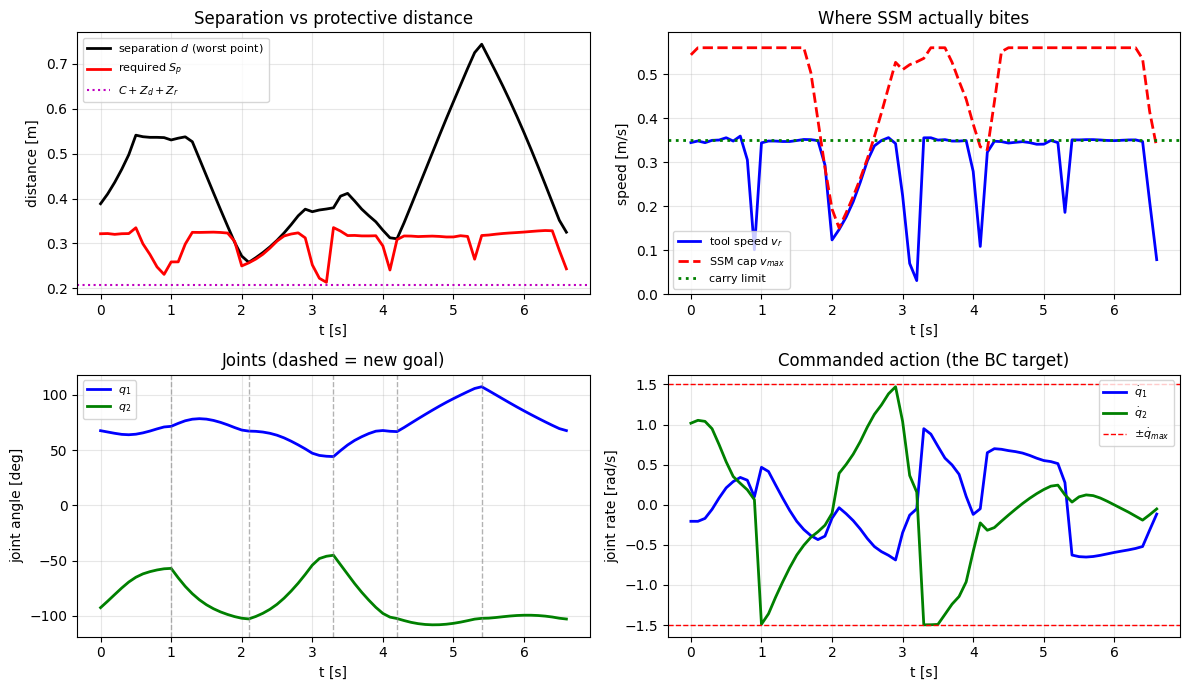

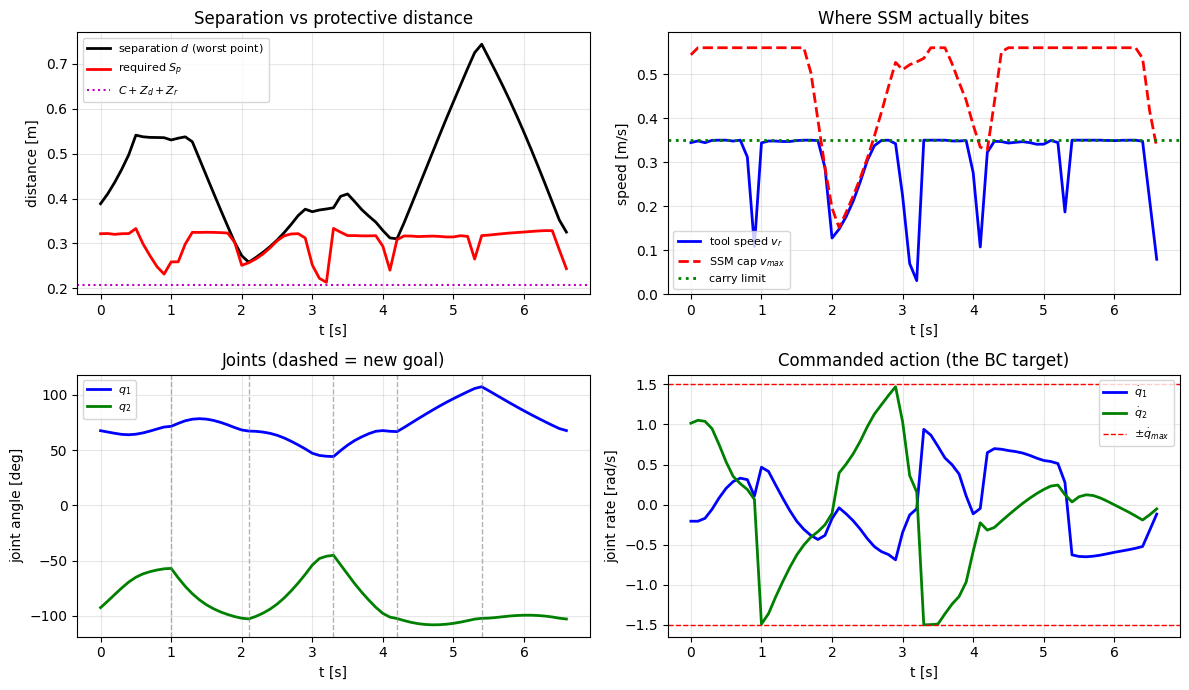

In [58]:
# [SELF-STUDY] the two dashboards -- find the difference
for pol, lab in [(policy, 'unfiltered'), (filtered, 'filtered')]:
    lg = sc.simulate(pol, scns[50], label=lab)
    sc.audit(lg)                       # adds d_worst / Sp_worst / margin
    viz.plot_run(lg); plt.show()

---
## **3.5 What this shows, and what it does not** — 4 min

In [59]:
grader.reset()
grader.q_d3_corr(corr, feature_names)
grader.q_active(active, D, sc.V_CARRY)
grader.q_features(features, X)
grader.q_no_drift(d_clone, d_expert)
grader.q_filter(z_f)
grader.summary()

  PASS  1.1  you correlated every feature with both actions
  PASS  1.2  correlations are between -1 and 1
  PASS  1.3  the goal columns carry the signal
  PASS  1.4  the operator columns do not
  PASS  SSM is the active limiter on a small minority of steps
  PASS  the tool is slower where SSM binds
  PASS  features() returns six numbers
  PASS  features() matches the stored column order
  PASS  the clone does NOT drift away from the training data
  PASS  the filter removes every violation
  PASS  and costs no goal-reach failures here

  11 / 11 checks passed


True

**It does show** that a network can reproduce a controller's behaviour closely;
that closely is not safely; and that the standard diagnosis was **measurably**
wrong here.

**It does not show** that behavioural cloning is unsuitable for safety-critical
control. It shows that *these six features* were insufficient on *this* cell,
and that the way you find that out is by measuring.

**The thesis is narrower and more useful:** the architecture determines what you
can guarantee, and you must know which part carries the guarantee. Here the
output `tanh` bounds the joint speed by construction — that is the network's
own guarantee, and the only one. Everything else rests on the filter.

### **Three sentences to leave with**

1. **A loss averaged over every row weights the rare rows by how often they
   occur.**
2. **Diagnose before you fix — the obvious explanation was measurably wrong.**
3. **A filter outside the network is a guarantee about the action, not about
   the network.**

---
> ### **[SELF-STUDY] 3.5b — the published comparison**
>
> **~5 min. What it shows:** the source paper reports **33.42 % / 40.67 %**
> unfiltered on a UR5 with 48 features, and finds the filter breaks
> goal-reaching for naively-trained networks — which is what DAGGER (Dataset
> Aggregation) pays for. We get a far lower rate, no drift, and no goal failures
> either way.
>
> **Do not report this as "we reproduced it, smaller."** Different robot, six
> features instead of forty-eight, two degrees of freedom instead of six: a
> **different phenomenon**, on an easier plant.
>
> **Stating a negative result as clearly as a positive one is the professional
> skill this day is really teaching.**

---
---
# **References**

### **The problem**

- **A. Nurbayeva and M. Rubagotti**, "Safely imitating predictive control
  policies for real-time human-aware manipulator motion planning: a dataset
  aggregation approach," *IEEE Access*, vol. 13, pp. 3204–3214, 2024.
  DOI 10.1109/ACCESS.2024.3524946. Code: `github.com/RCLlab/ur5_dagger`.
- **A. Nurbayeva, A. Shintemirov and M. Rubagotti**, "Deep imitation learning
  of nonlinear model predictive control laws for a safe physical human–robot
  interaction," *IEEE Trans. Industrial Informatics*, vol. 19, no. 7,
  pp. 8384–8395, 2023.
- **S. Ross, G. Gordon and J. A. Bagnell**, "A reduction of imitation learning
  and structured prediction to no-regret online learning," *AISTATS*, JMLR
  W&CP vol. 15, pp. 627–635, 2011. **DAGGER (Dataset Aggregation)**,
  Algorithm 3.1.
- **D. A. Pomerleau**, "ALVINN: an autonomous land vehicle in a neural
  network," *Advances in Neural Information Processing Systems 1*,
  pp. 305–313, 1989.

### **The methods**

- **Multilayer perceptron.** I. Goodfellow, Y. Bengio and A. Courville,
  *Deep Learning*, MIT Press, 2016, ch. 6. **Notation follows this text.**
- **Backpropagation.** D. E. Rumelhart, G. E. Hinton and R. J. Williams,
  "Learning representations by back-propagating errors," *Nature* **323**,
  pp. 533–536, 1986.
- **Adam.** D. P. Kingma and J. Ba, "Adam: a method for stochastic
  optimization," *ICLR*, 2015. arXiv:1412.6980.
- **Initialisation.** The code uses $\mathcal{N}(0, \sqrt{2/n_{in}})$ —
  K. He, X. Zhang, S. Ren and J. Sun, "Delving deep into rectifiers," *ICCV*,
  2015, pp. 1026–1034 — which was **derived for ReLU**. For `tanh` the
  conventional choice is X. Glorot and Y. Bengio, "Understanding the difficulty
  of training deep feedforward neural networks," *AISTATS*, 2010, with variance
  $2/(n_{in}+n_{out})$. Adam absorbs most of the difference; see §2.3b.
- **k-d trees**, for the nearest-neighbour distance. J. L. Bentley,
  "Multidimensional binary search trees used for associative searching,"
  *Comm. ACM* **18**(9), pp. 509–517, 1975. Used via `scipy.spatial.cKDTree`.
- **Interior-point solver**, for the filter. A. Wächter and L. T. Biegler,
  "On the implementation of an interior-point filter line-search algorithm for
  large-scale nonlinear programming," *Math. Prog.* **106**(1), pp. 25–57, 2006.
- **CasADi.** J. A. E. Andersson, J. Gillis, G. Horn, J. B. Rawlings and
  M. Diehl, *Math. Prog. Computation* **11**(1), pp. 1–36, 2019.
- **Bishop**, *Pattern Recognition and Machine Learning*, Springer, 2006, ch. 5
  — backpropagation derived rather than asserted.